In [57]:
%load_ext autoreload
%autoreload 2

# Set plotting parameters for figures
from matplotlib import rcParams
rcParams['font.family'] = 'Arial'
rcParams['pdf.fonttype'] = 42  # Use TrueType fonts
rcParams['axes.linewidth'] = 0.5
rcParams['xtick.major.width'] = 0.5
rcParams['ytick.major.width'] = 0.5
rcParams['savefig.dpi'] = 300  # Ensure a high resolution

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [58]:
# Load raw fluorescein traces
import pandas as pd

fluor_timecourse_raw = pd.read_csv('../../data/fluorescein_calibration_experiments/fluorescein_timecourse.csv')
fluor_timecourse_raw

,Frame,Fluor2to8_switchOn3_tr2_000,Fluor3_switchOn3then8_no2acsf_120s_001,Fluor3_switchOn3then8_yes2acsf_90s_trial2_001,Fluor3_switchOn3then8_yes2acsf_120s_001,Fluor3_swtichOn3then8_yes2acsf_50sImaging
0,1,8136.0972,8136.2949,8135.9463,8136.7646,8136.403
1,2,8136.2588,8136.3784,8135.7720,8136.5942,8136.312
2,3,8136.4282,8136.3154,8135.7603,8136.5088,8136.314
3,4,8136.5059,8136.1577,8135.9009,8136.6514,8135.983
4,5,8136.6143,8136.0112,8135.9917,8136.7988,8136.120
...,...,...,...,...,...,...
895,896,8136.3335,8136.3945,8136.2852,8136.8896,8137.186
896,897,8136.5693,8136.0674,8136.3477,8136.8354,8137.127
897,898,8136.6841,8136.6074,8136.5439,8136.7734,8137.010
898,899,8136.5220,8136.6299,8136.3628,8136.8174,8136.928


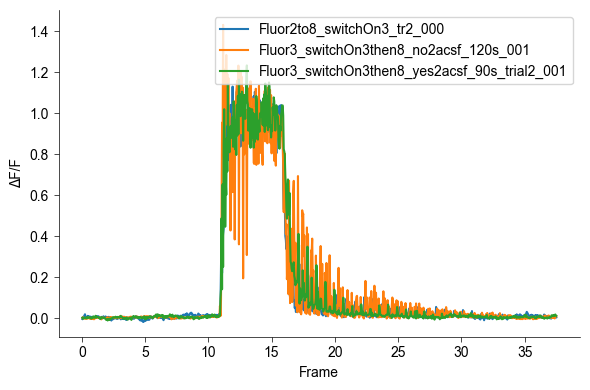

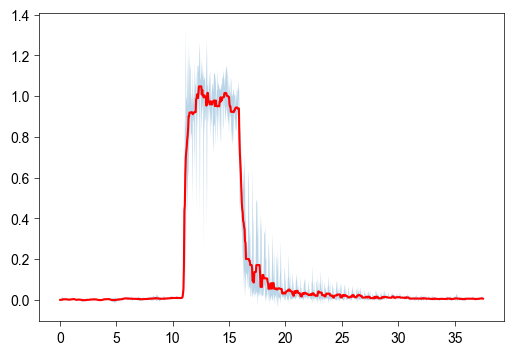

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = fluor_timecourse_raw
time_col = 'Frame'

# Identify fluorescence columns
num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
if time_col in num_cols:
    num_cols.remove(time_col)
cell_cols = num_cols[:3]

# Baseline and dF/F (10th percentile)
F0 = df[cell_cols].quantile(0.10)
fluor_dff = (df[cell_cols] - F0) / F0

# Normalize df/f by the 95th percentile
fluor_dff = fluor_dff / fluor_dff.quantile(0.95)

frame_rate = 24
# Convert frames to seconds (9 Hz)
if time_col:
    seconds = df[time_col].values / frame_rate
else:
    seconds = np.arange(len(df)) / frame_rate


# Plot
plt.figure(figsize=(6, 4))
for c in fluor_dff.columns:
    plt.plot(seconds, fluor_dff[c].values, label=c)

# Despine
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xlabel("Frame")
plt.ylabel("ΔF/F")
plt.legend()
plt.tight_layout()
plt.savefig("dff_traces.png", dpi=300)
plt.show()

# Plot mean and std using seaborn
import seaborn as sns
fig, ax = plt.subplots(figsize=(6, 4))
#sns.lineplot(x=seconds, y=fluor_dff.mean(axis=1), ax=ax)
ax.fill_between(seconds, fluor_dff.mean(axis=1) - fluor_dff.std(axis=1), fluor_dff.mean(axis=1) + fluor_dff.std(axis=1), alpha=0.3)

# Smooth the mean trace using median filter
from scipy.signal import medfilt
smoothed_mean = medfilt(fluor_dff.mean(axis=1), kernel_size=9)
ax.plot(seconds, smoothed_mean, color='red', label='Smoothed Mean')

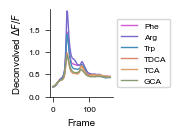

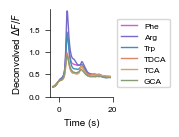

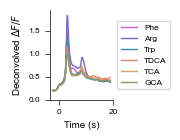

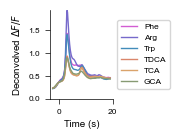

In [60]:
# Overlay with mean neuron timecourse

from catrace.run.run_average_timecourse import run_average_timecourse, RunAverageTimecourseParams

params = RunAverageTimecourseParams(
    config_file = '../juvenile_dataset_without14mm_phearg.json',
    assembly_name = '',
    do_plot_per_fish = False,
    dff = dff,
    figsize=(1.9, 1.5),
    cut_time=2.3,
    odor_colors = ['#d25dd2', '#766acb', '#428cba', '#da866b', '#daa36b', '#879a73'],
    ylim=(0, 1.95), # (0, 0.26),
    label_fontsize=7,
    tick_label_fontsize=6,
    legend_fontsize=6,
    convert_to_rate=False, # The data is already in rate
)

if params.assembly_name == '':
    assembly_label = 'all_neurons'
else:
    assembly_label = params.assembly_name

dff, outfigs = run_average_timecourse(params)

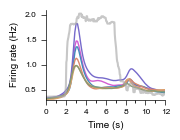

In [61]:
for name in ['fig_time', 'fig_naive_time', 'fig_trained_time']:
    fig = outfigs[name]
    ax = fig.get_axes()[0]
    ax.set_xlim([0, 12])
    ax.set_ylim([0.3, 2.1])#[0.02, 0.28])
    # Set xticks with interval of 2 using multiplelocator
    from matplotlib.ticker import MultipleLocator
    ax.xaxis.set_major_locator(MultipleLocator(2))
    ax.xaxis.set_minor_locator(MultipleLocator(1))
    # Set ylabel
    ylabel = 'Firing rate (Hz)'
    ax.set_ylabel(ylabel)
    # Remove legend
    if ax.get_legend() is not None:
        ax.get_legend().remove()

    # Plot the fluorescein mean trace on top
    ax.plot(seconds-9, smoothed_mean*1.6+0.35, color='darkgray', label='Fluorescein Smoothed Mean', alpha=0.65)
    # Tight layout
    fig.tight_layout()

outfigs['fig_naive_time']


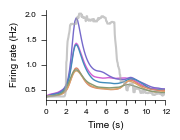

In [62]:
outfigs['fig_trained_time']

In [63]:
import os
from catrace.for_paper import save_figure_for_paper
paper_fig_root_dir = '/tungstenfs/scratch/gfriedri/hubo/Dp_manifold/figures_for_paper'
dataset_name = 'juvenile'
paper_fig_dir = os.path.join(paper_fig_root_dir, dataset_name, 'timecourse_with_odor_fluorescein_calibraion')
os.makedirs(paper_fig_dir, exist_ok=True)
save_figure_for_paper(outfigs['fig_time'], f'{dataset_name}_timecourse_with_odor_calibration', paper_fig_dir)
save_figure_for_paper(outfigs['fig_naive_time'], f'{dataset_name}_timecourse_naive_with_odor_calibration', paper_fig_dir)
save_figure_for_paper(outfigs['fig_trained_time'], f'{dataset_name}_timecourse_trained_with_odor_calibration', paper_fig_dir)
